<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/RegressionNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("salary.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Visualize Training Set results

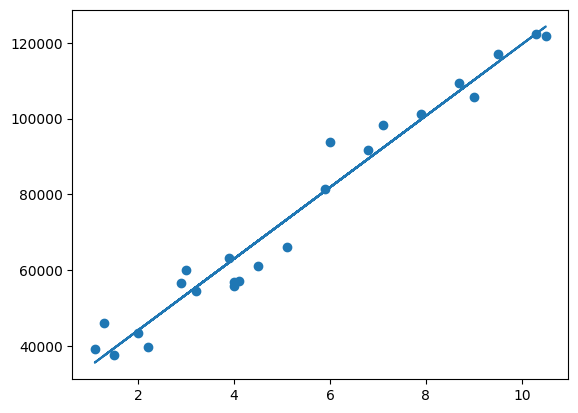

In [2]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)

plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train))

## Visualize Test Set results

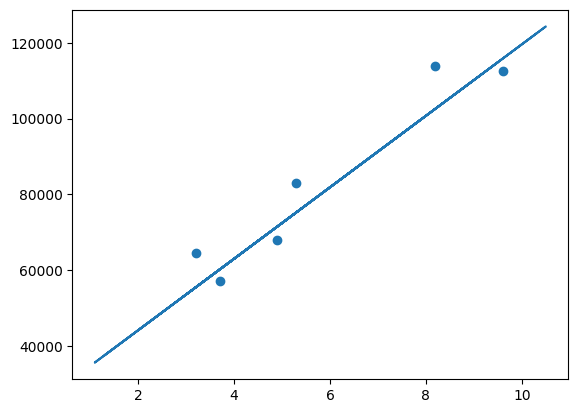

In [3]:
plt.scatter(X_test, y_test)
plt.plot(X_train, regressor.predict(X_train))

In [4]:
regressor.predict([[10]]) # salary of an employee with 10 years of experience
# predict method expects a 2D array

array([119559.73624209])

In [5]:
regressor.coef_, regressor.intercept_
# Salary = 9423 × YearsExperience + 25321

(array([9423.81532303]), np.float64(25321.583011776813))

# Multiple Linear Regression

In [6]:
df = pd.read_csv("startups.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')

X = np.array(transformer.fit_transform(X))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [7]:
regressor = LinearRegression()

regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)

np.set_printoptions(precision=2)

np.concatenate((predictions.reshape(len(predictions), 1), y_test.reshape(len(y_test), 1)), 1)

array([[126362.88, 134307.35],
       [ 84608.45,  81005.76],
       [ 99677.49,  99937.59],
       [ 46357.46,  64926.08],
       [128750.48, 125370.37],
       [ 50912.42,  35673.41],
       [109741.35, 105733.54],
       [100643.24, 107404.34],
       [ 97599.28,  97427.84],
       [113097.43, 122776.86]])

# Polynomial Linear Regression

In [8]:
df = pd.read_csv("position_salaries.csv")

X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values

df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


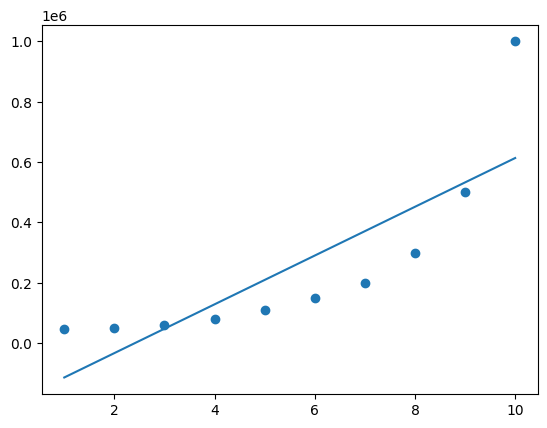

In [9]:
# linear regressor

linear_regressor = LinearRegression()

linear_regressor.fit(X, y)

plt.scatter(X, y)
plt.plot(X, linear_regressor.predict(X))

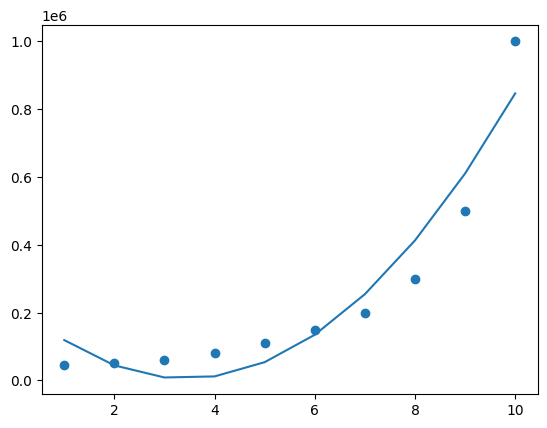

In [10]:
# polynomial regressor (degree 2)

from sklearn.preprocessing import PolynomialFeatures

polynomial_regressor = PolynomialFeatures(degree=2)

X_poly = polynomial_regressor.fit_transform(X)

linear_regressor_2 = LinearRegression()

linear_regressor_2.fit(X_poly, y)

plt.scatter(X, y)
plt.plot(X, linear_regressor_2.predict(X_poly))

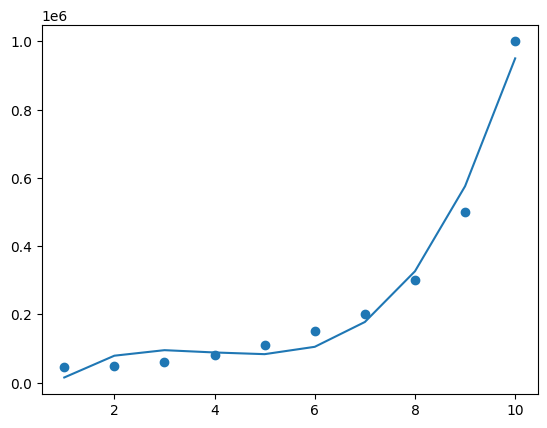

In [11]:
# polynomial regressor (degree 3)

polynomial_regressor = PolynomialFeatures(degree=3)

X_poly = polynomial_regressor.fit_transform(X)

linear_regressor_2 = LinearRegression()

linear_regressor_2.fit(X_poly, y)

plt.scatter(X, y)
plt.plot(X, linear_regressor_2.predict(X_poly))

/tmp/ipykernel_67784/1509374834.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


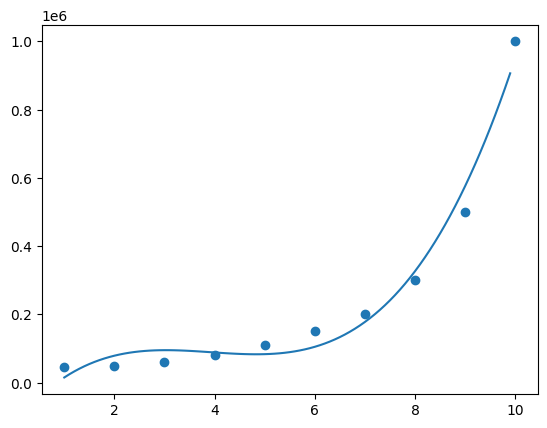

In [12]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y)
plt.plot(X_grid, linear_regressor_2.predict(polynomial_regressor.fit_transform(X_grid)))

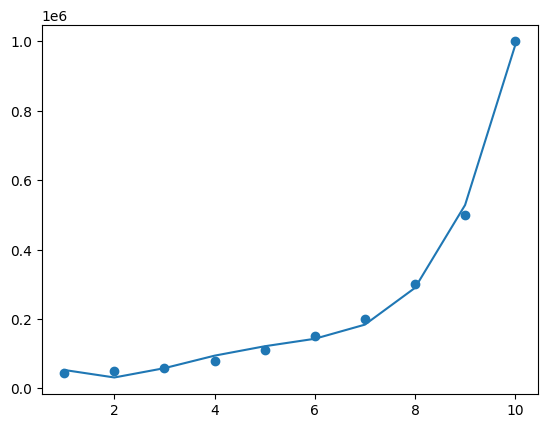

In [13]:
# polynomial regressor (degree 4)

polynomial_regressor = PolynomialFeatures(degree=4)

X_poly = polynomial_regressor.fit_transform(X)

linear_regressor_2 = LinearRegression()

linear_regressor_2.fit(X_poly, y)

plt.scatter(X, y)
plt.plot(X, linear_regressor_2.predict(X_poly))

/tmp/ipykernel_67784/1509374834.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


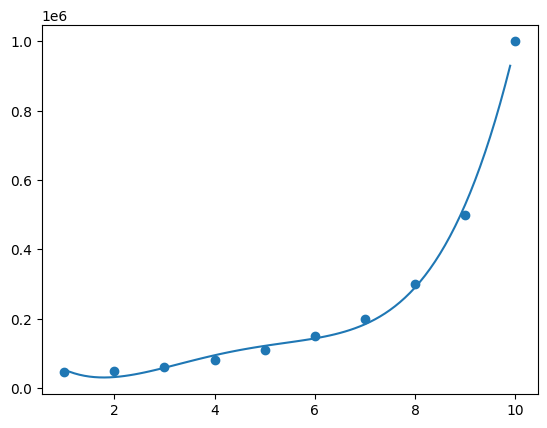

In [14]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y)
plt.plot(X_grid, linear_regressor_2.predict(polynomial_regressor.fit_transform(X_grid)))

In [15]:
linear_regressor.predict([[6.5]]), linear_regressor_2.predict(polynomial_regressor.fit_transform([[6.5]]))

(array([330378.79]), array([158862.45]))

# SVR

[[170370.02]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


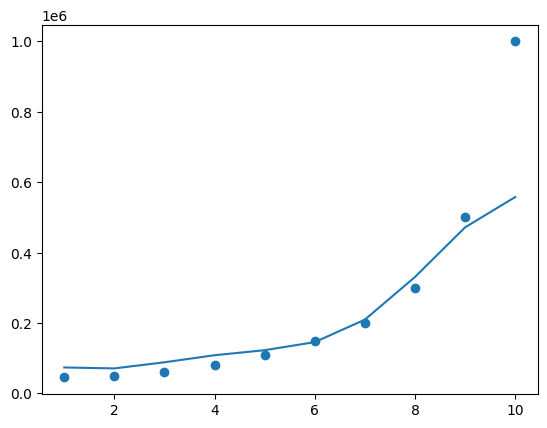

In [16]:
df = pd.read_csv("position_salaries.csv")

X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
y = y.reshape(len(y), 1)

from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

from sklearn.svm import SVR

regressor = SVR(kernel='rbf') # gaussian rbf kernel (radial basis function)

regressor.fit(X, y)

print(scaler_y.inverse_transform(regressor.predict(scaler_X.transform([[6.5]])).reshape(-1, 1)))

plt.scatter(scaler_X.inverse_transform(X), scaler_y.inverse_transform(y))
plt.plot(scaler_X.inverse_transform(X), scaler_y.inverse_transform(regressor.predict(X).reshape(-1, 1)))


/tmp/ipykernel_67784/229783141.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(scaler_X.inverse_transform(X)), max(scaler_X.inverse_transform(X)), 0.1)


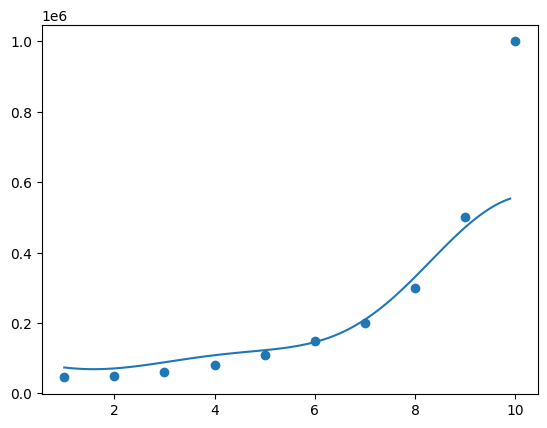

In [17]:
X_grid = np.arange(min(scaler_X.inverse_transform(X)), max(scaler_X.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(scaler_X.inverse_transform(X), scaler_y.inverse_transform(y))
plt.plot(X_grid, scaler_y.inverse_transform(regressor.predict(scaler_X.transform(X_grid)).reshape(-1, 1)))

# Decision Tree

[150000.]


/tmp/ipykernel_67784/576681109.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


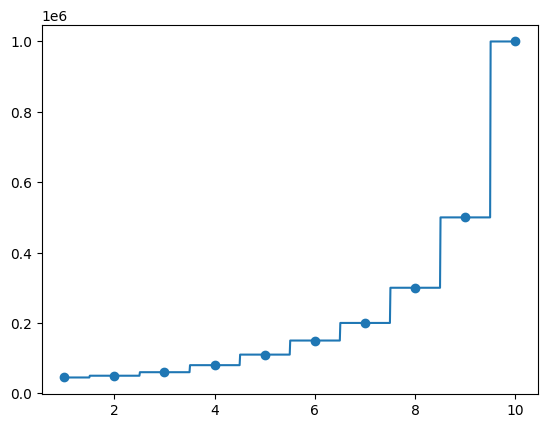

In [18]:
df = pd.read_csv("position_salaries.csv")

X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values

from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()

regressor.fit(X, y)

print(regressor.predict([[6.5]]))

X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y)
plt.plot(X_grid, regressor.predict(X_grid))

# Random Forest

[167000.]


/tmp/ipykernel_67784/1738521902.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


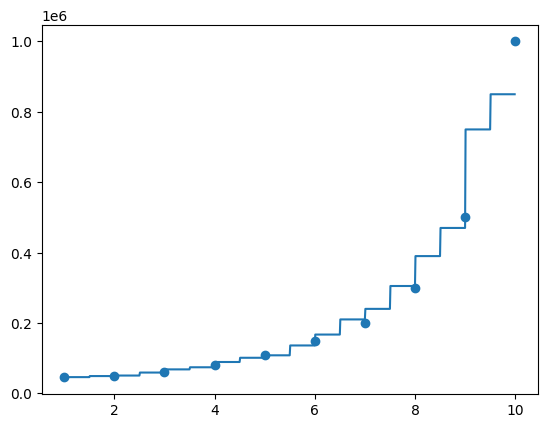

In [19]:
df = pd.read_csv("position_salaries.csv")

X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values

from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=10, random_state=0)

regressor.fit(X, y)

print(regressor.predict([[6.5]]))

X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y)
plt.plot(X_grid, regressor.predict(X_grid))

# Regression Model Selection

In [20]:
df = pd.read_csv('data2.csv')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [21]:
# Multiple Linear Regression

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)
from sklearn.metrics import r2_score
print("Multiple Linear Regression: ", r2_score(y_test, predictions))

# Polynomial Regression

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
polynomial_regressor = PolynomialFeatures(degree=4)
X_poly = polynomial_regressor.fit_transform(X_train)
regressor = LinearRegression()
regressor.fit(X_poly, y_train)
predictions = regressor.predict(polynomial_regressor.transform(X_test))
print("Polynomial Regression: ", r2_score(y_test, predictions))

# SVR

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
y = y.reshape(len(y), 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
y_train = scaler_y.fit_transform(y_train)
regressor = SVR(kernel='rbf')
regressor.fit(X_train, y_train)
predictions = scaler_y.inverse_transform(regressor.predict(scaler_X.transform(X_test)).reshape(-1, 1))
print("SVR: ", r2_score(y_test, predictions))

# Decision Tree

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)
print("Decision Tree Regressor: ", r2_score(y_test, predictions))

# Random Forest

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
regressor = RandomForestRegressor(n_estimators=10, random_state=0)
regressor.fit(X_train, y_train)
predictions = regressor.predict(X_test)
print("Random Forest Regressor: ", r2_score(y_test, predictions))

Multiple Linear Regression:  0.9301046431962188
Polynomial Regression:  0.9431454276805127


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR:  0.9468461924240114
Decision Tree Regressor:  0.9325878063100713
Random Forest Regressor:  0.9591169807440535
